# Исследовательский трек: Решение задачи детекции текста как задачи сегментации

Набор данных - "Total Text - Scene Text Recognition", https://www.kaggle.com/datasets/ipythonx/totaltextstr.


TOTAL-TEXT — это набор данных английского текста с изогнутыми линиями, основанный на отдельных словах. Он состоит из 1555 изображений с более чем тремя различными ориентациями текста: горизонтальной, многоориентированной и изогнутой, — каждый из которых уникален.

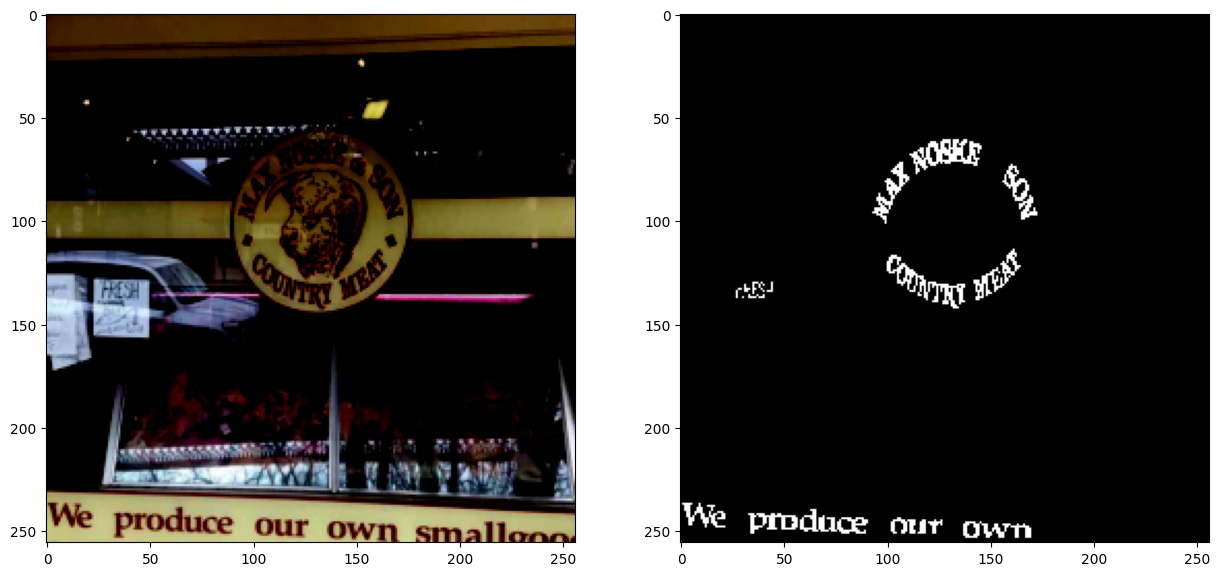

## Задача сегментации

Модели обучались 30 эпох, в качестве метрики использовалась IOU. Данные обучения и результаты находятся в ноутбуке - https://colab.research.google.com/drive/1ovYuueWiCPLEVyZbFYkkyJW78UWAXCeW?usp=sharing.

В семантической сегментации выход модели — карта того же размера, что и GT-маска. Метрика должна ответить на один вопрос: насколько предсказанная маска совпадает с истинной. Для этого идеально подходит метрика IoU (Jaccard index).

**Архитектура SegNet**

IOU = 0.17

Модель стабильна, при большем количестве ресурсов можно продолжить обучение для исследования. Но по сравнению с другими архитектурами самая слабая, подходит только для исследования, потому что архитектура простая.


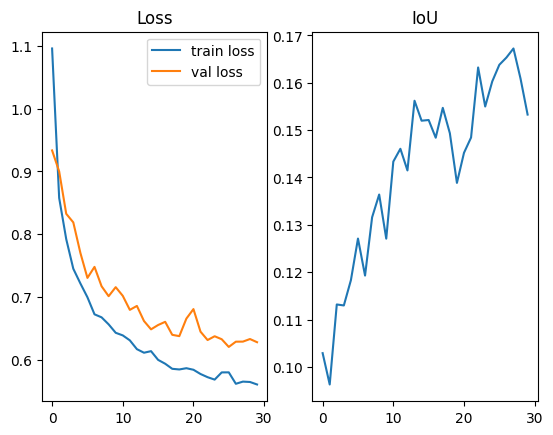

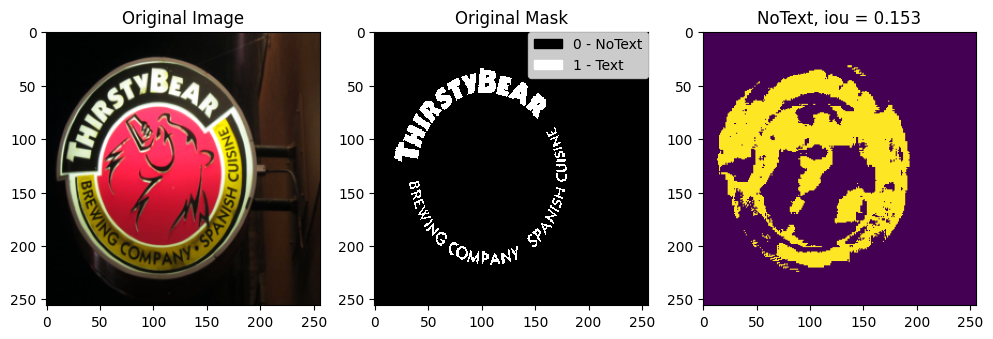

**Готовый DeepLabV3**

IOU = 0.31

Модель по качеству значительно превосходит SegNet, но на 30 эпохах уступает Unet. Можно было также продолжить обучение, так как ошибка на валидации падает, а метрика IOU растет.

В результате работы уже видны очертания текста. Я считаю, что для дальнейшей детекции и анализа, можно было бы использовать и результаты выхода этой модели.

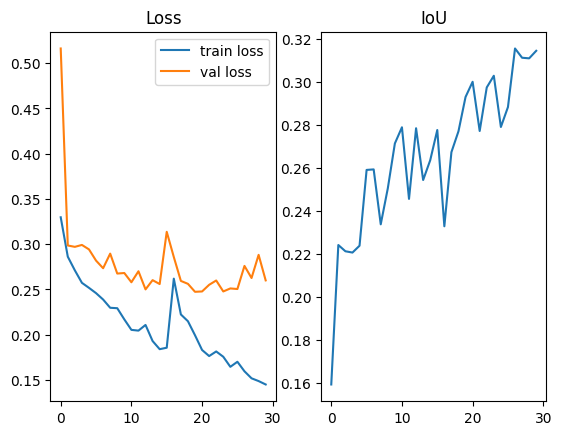

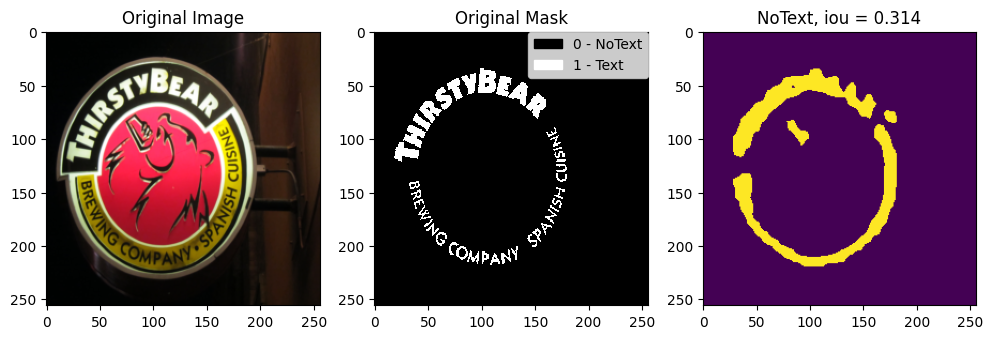

**Архитектура UNet**

IOU = 0.44

UNet превосходит две другие модели на 30 эпохах. Обучение также можно было бы продолжить.

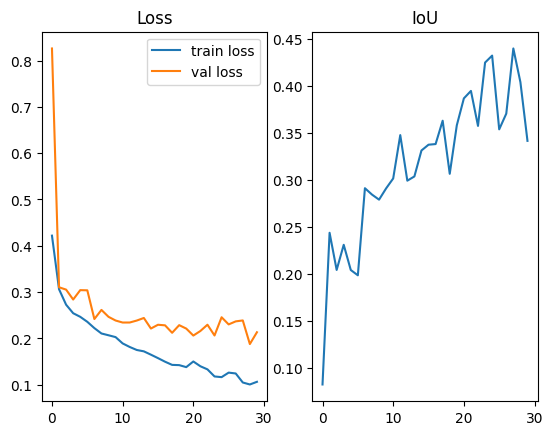

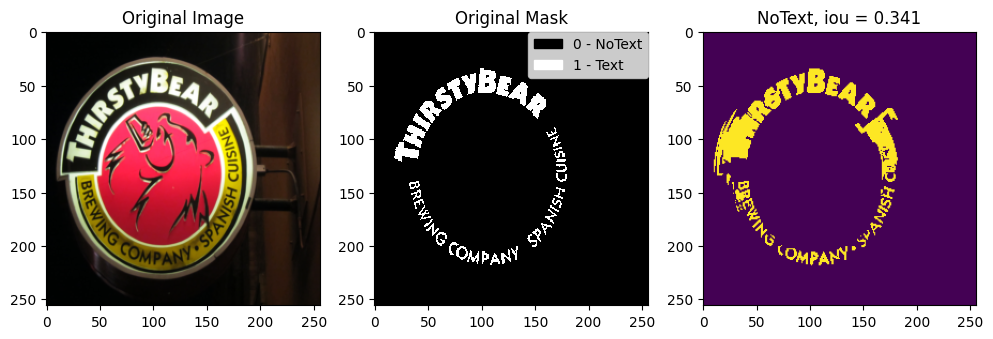

**Выводы:**

На 30 эпохах самая лучшая модель - UNet. Но при дальнейшем обучении, я считаю, что DeepLabV3 может превзойти ее.

Дальше для задачи детекции я буду использовать выход модели Unet после 27 эпохи, где метрика IOU = 0.44, наилучшая.

Ниже приведены примеры итоговой сегментации, которые в дальнейшем использовались для детекции.

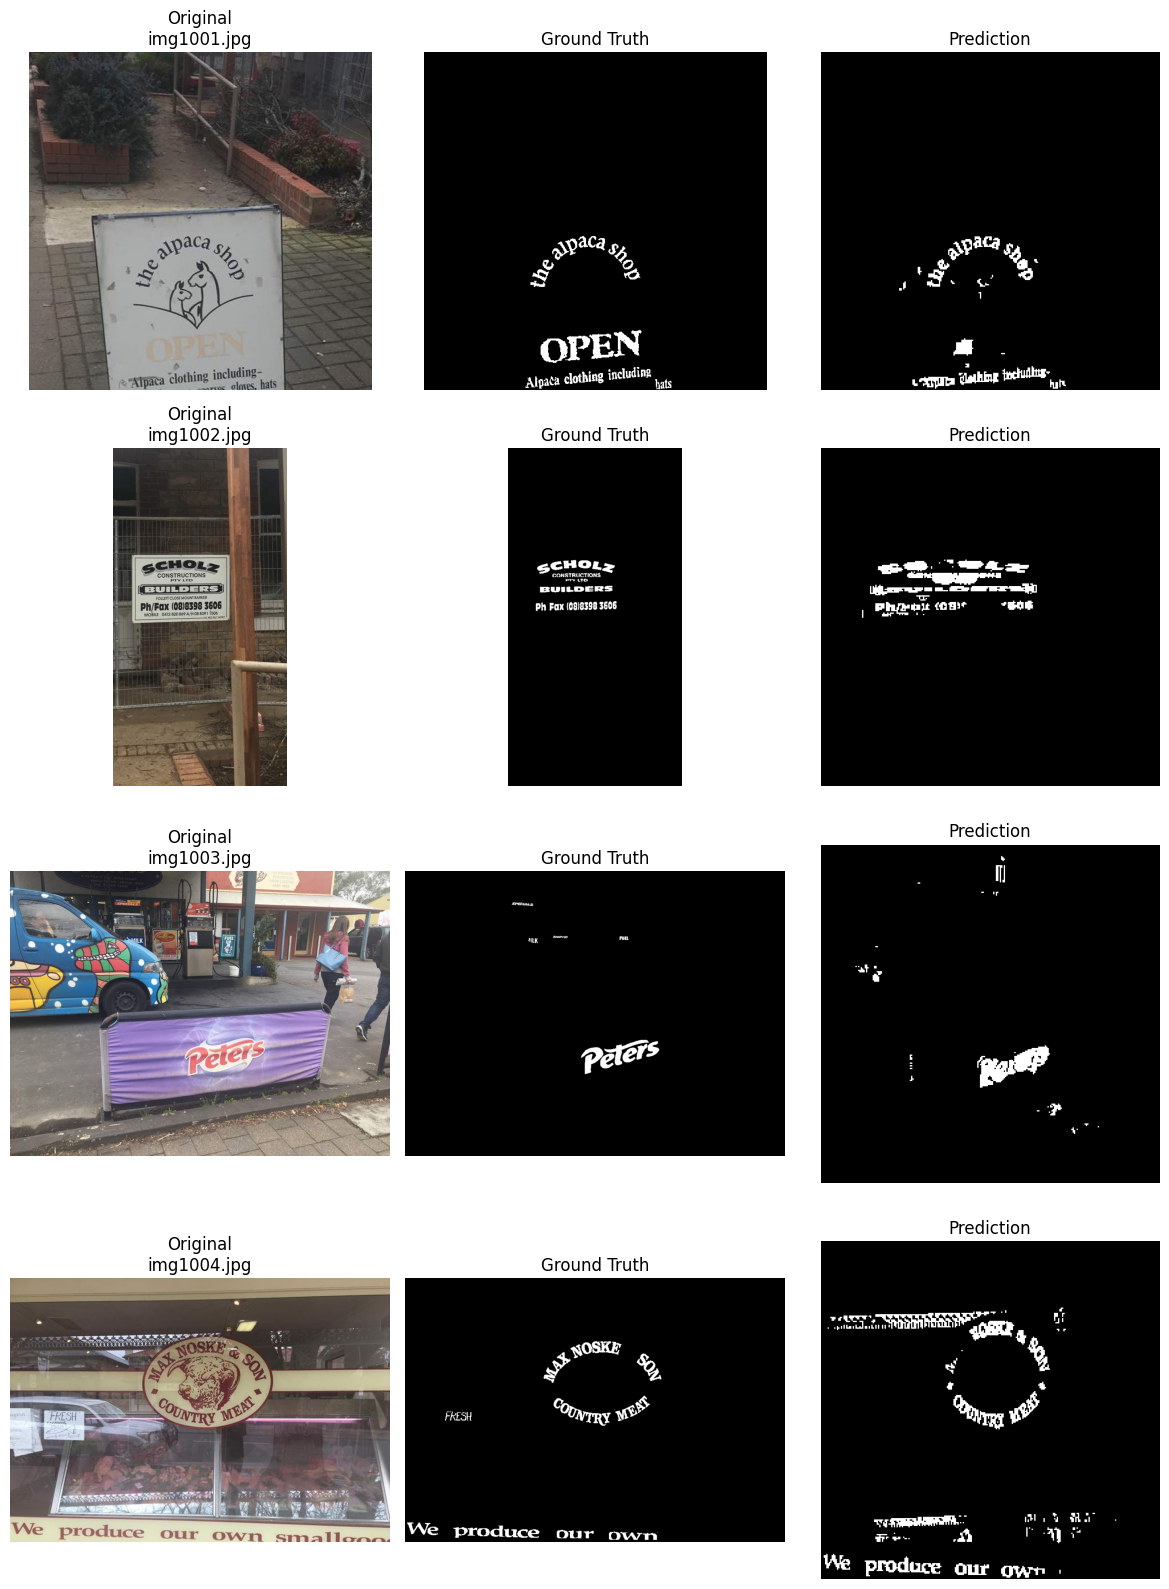

##Задача детекции

Модели обучались на разном количестве эпох, потому что ресурсы ограничены и мне хотелось достичь максимально хороших результатов для каждой из моделей. В качестве метрики использовалась mAP и mAP50(усреднённая точность при одном пороге IoU = 0.5).

Модель детекции может выдать 0, 5, 50 или 5000 боксов на одной картинке. Простой IoU здесь не работает — нужен способ сравнить множество предсказаний с множеством GT. Для этой задачи подходит метрика mAP.

Самописные детекторы - https://colab.research.google.com/drive/1GFmr21-nnTrE6Z758QADHtcT3SiRbhAq?usp=sharing.

YOLOv8 - https://colab.research.google.com/drive/1irb5Mutzo3Sn-F2RNjW5RwYu-P5URwMg?usp=sharing.

**Одноуровневый якорный однопроходный детектор текста на базе EfficientNet**

mAP50 = 0.2736

Архитектура состоит из трёх стандартных блоков:

1. Backbone
EfficientNet-B0 (из timm, pretrained на ImageNet), заморожен для быстрого обучения. Берётся предпоследняя feature map (out_indices=(-2,)) для сохранения пространственного разрешения — важно для мелких текстовых областей.

2. Neck — Simplified FPN
Одиночная свёртка 3×3 + BatchNorm + ReLU, приводящая каналы backbone к neck_n_channels=256. Без multi-scale пирамиды, без latéral/top-down связей — отсюда «Simplified».

3. Detection Head
Общая свёртка 3×3, затем две параллельные ветви (1×1 conv)

Модель обучалась на 30 эпохах, после 15 эпохи метрика mAP падает, модель переобучается. Простая архитектура, которая показала не плохое качество уже на 11 эпохе, но хуже чем YOLOv8.

Из-за простоты архитектуры модели сложно находить текст в виде изогнутых линий, на итоговом рисунке это отчетливо видно.

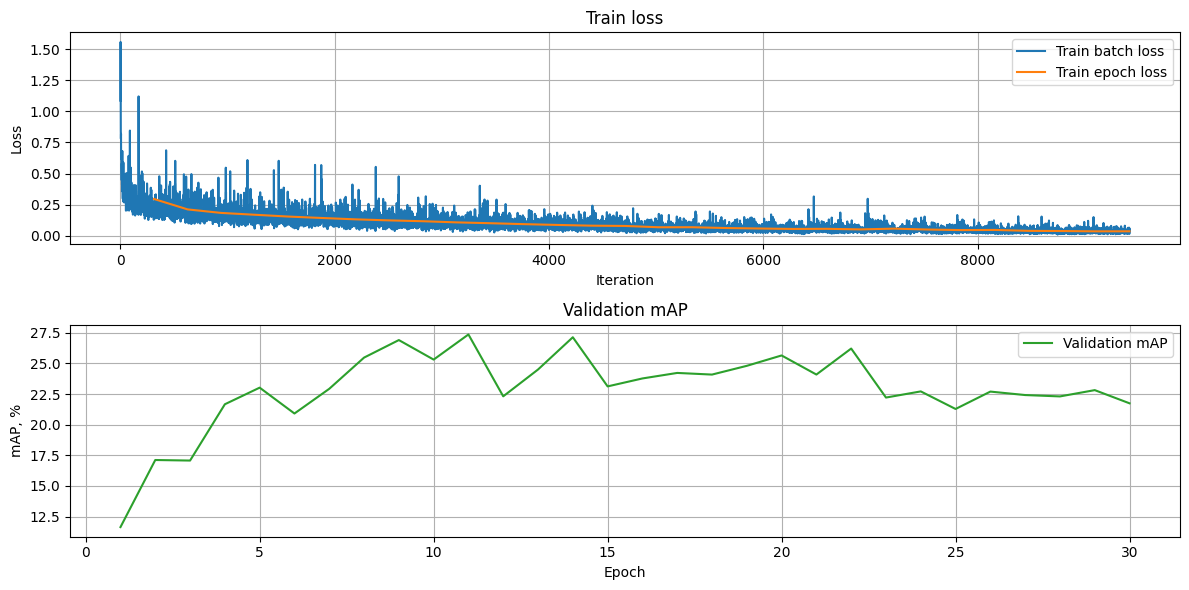

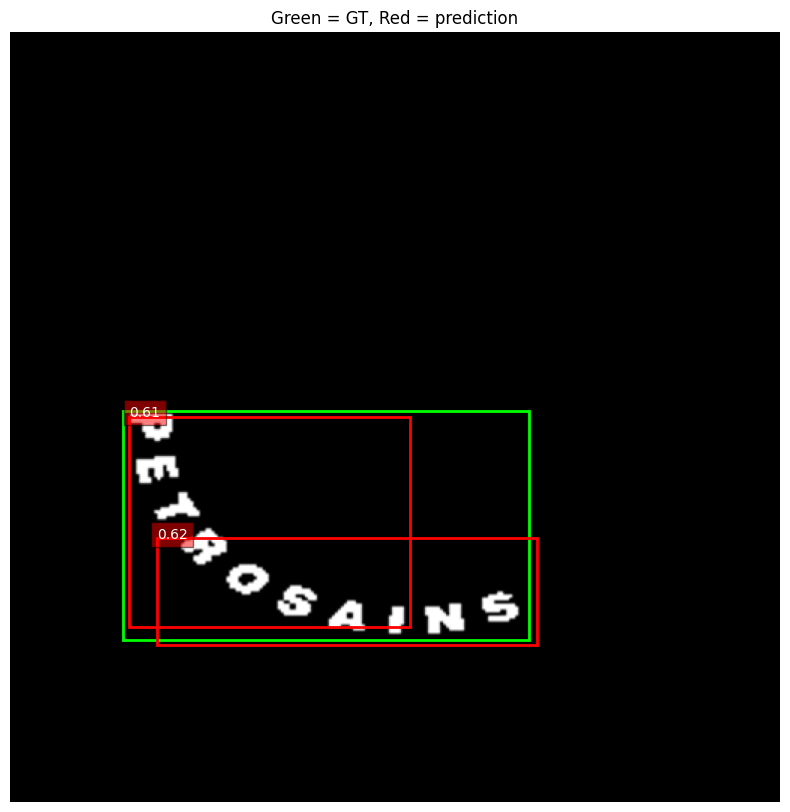

**Многоуровневый якорный однопроходный детектор с Feature Pyramid Network**

mAP50 = 0.0786

Архитектура
1. Backbone — EfficientNet-B0 (timm)
Предобучен на ImageNet. Извлекаются три уровня feature maps (out_indices=(-3, -2, -1)) — от более крупного пространственного разрешения к самому мелкому. Backbone разморожен полностью (fine-tuning всей сети).

2. Neck — Feature Pyramid Network (FPN)
Классическая FPN из статьи Lin et al. (2017):

Латеральные свёртки 1×1 приводят каждый уровень к общему числу каналов (256);
Top-down pathway: upsample nearest neighbor + поэлементное сложение с латеральным признаком;
Сглаживающие свёртки 3×3 после каждого суммирования (extra_conv=True).
На выходе — пирамида [P3, P4, P5] с одинаковой размерностью каналов.

3. Head — три независимые ветви (decoupled heads)
Общая свёртка 3×3 + ReLU, затем три параллельные 1×1 свёртки.

Данная модель заняла почти все мое время, работы над проектом. Финальное обучение прошло на 50 эпохах, но модель так и не обучилась. Объясняю это тем, что мне неудалось подобрать нужные параметры и что допущена критичная ошибка в архитектуре. Возможно, архитектура не подходит для решения данной задачи.

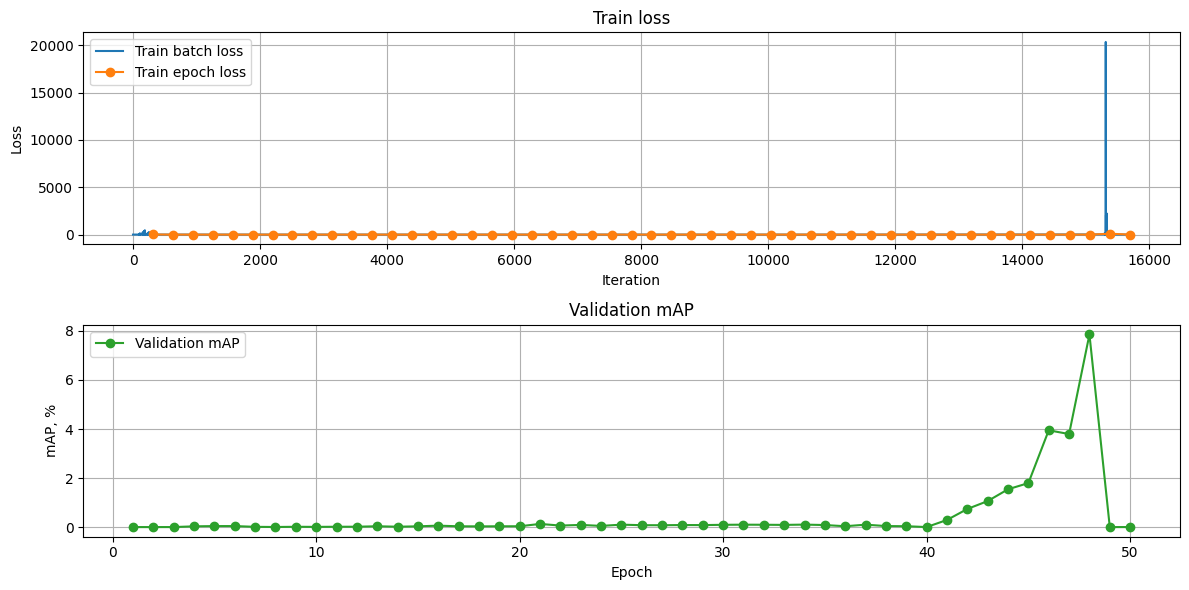

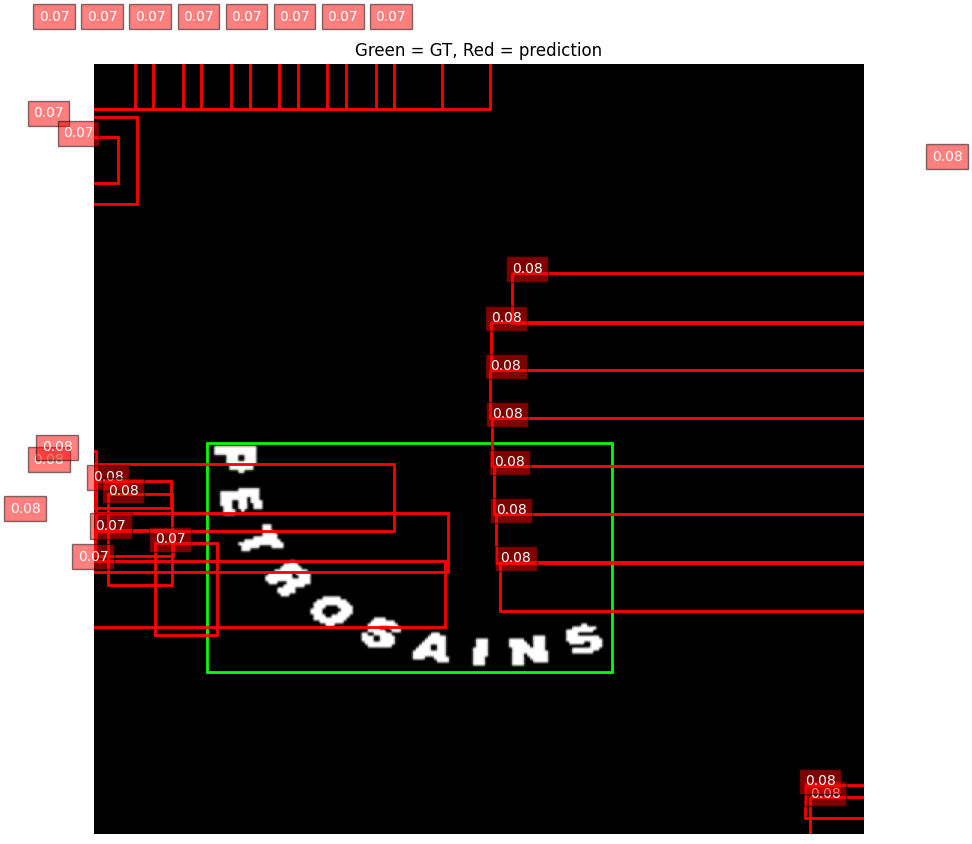

**Готовая YOLOv8**

mAP50 = 0.59

Данная модель обучалась на 200 эпохах, после 100 эпохи на графике видно переобучение. YOLOv8 показала наилучшее качество.

На выходе модель практически безошибочно находит текст.

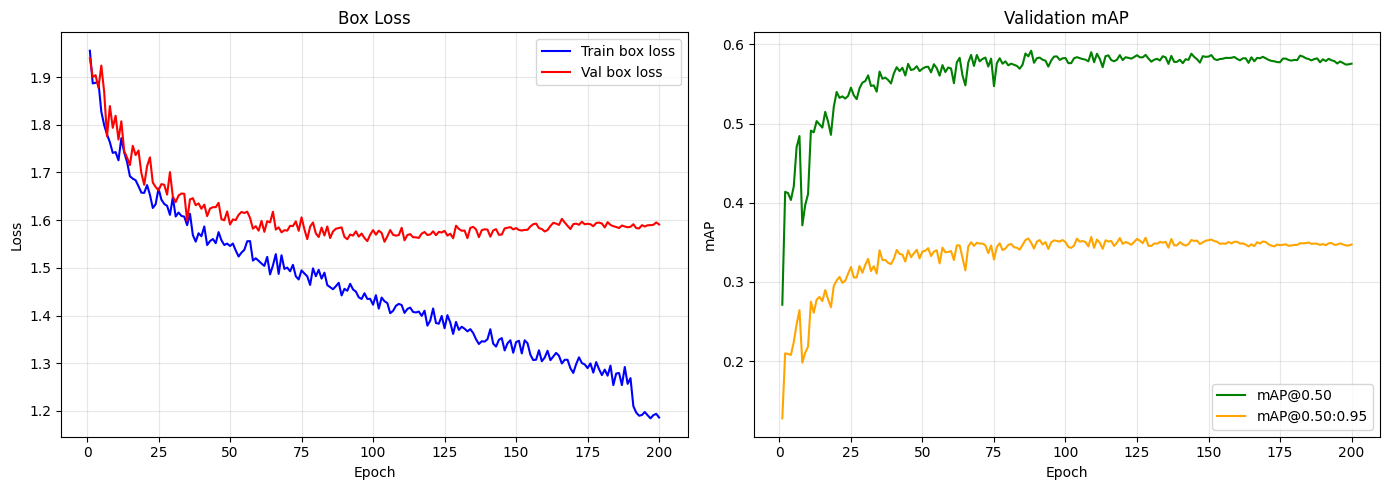

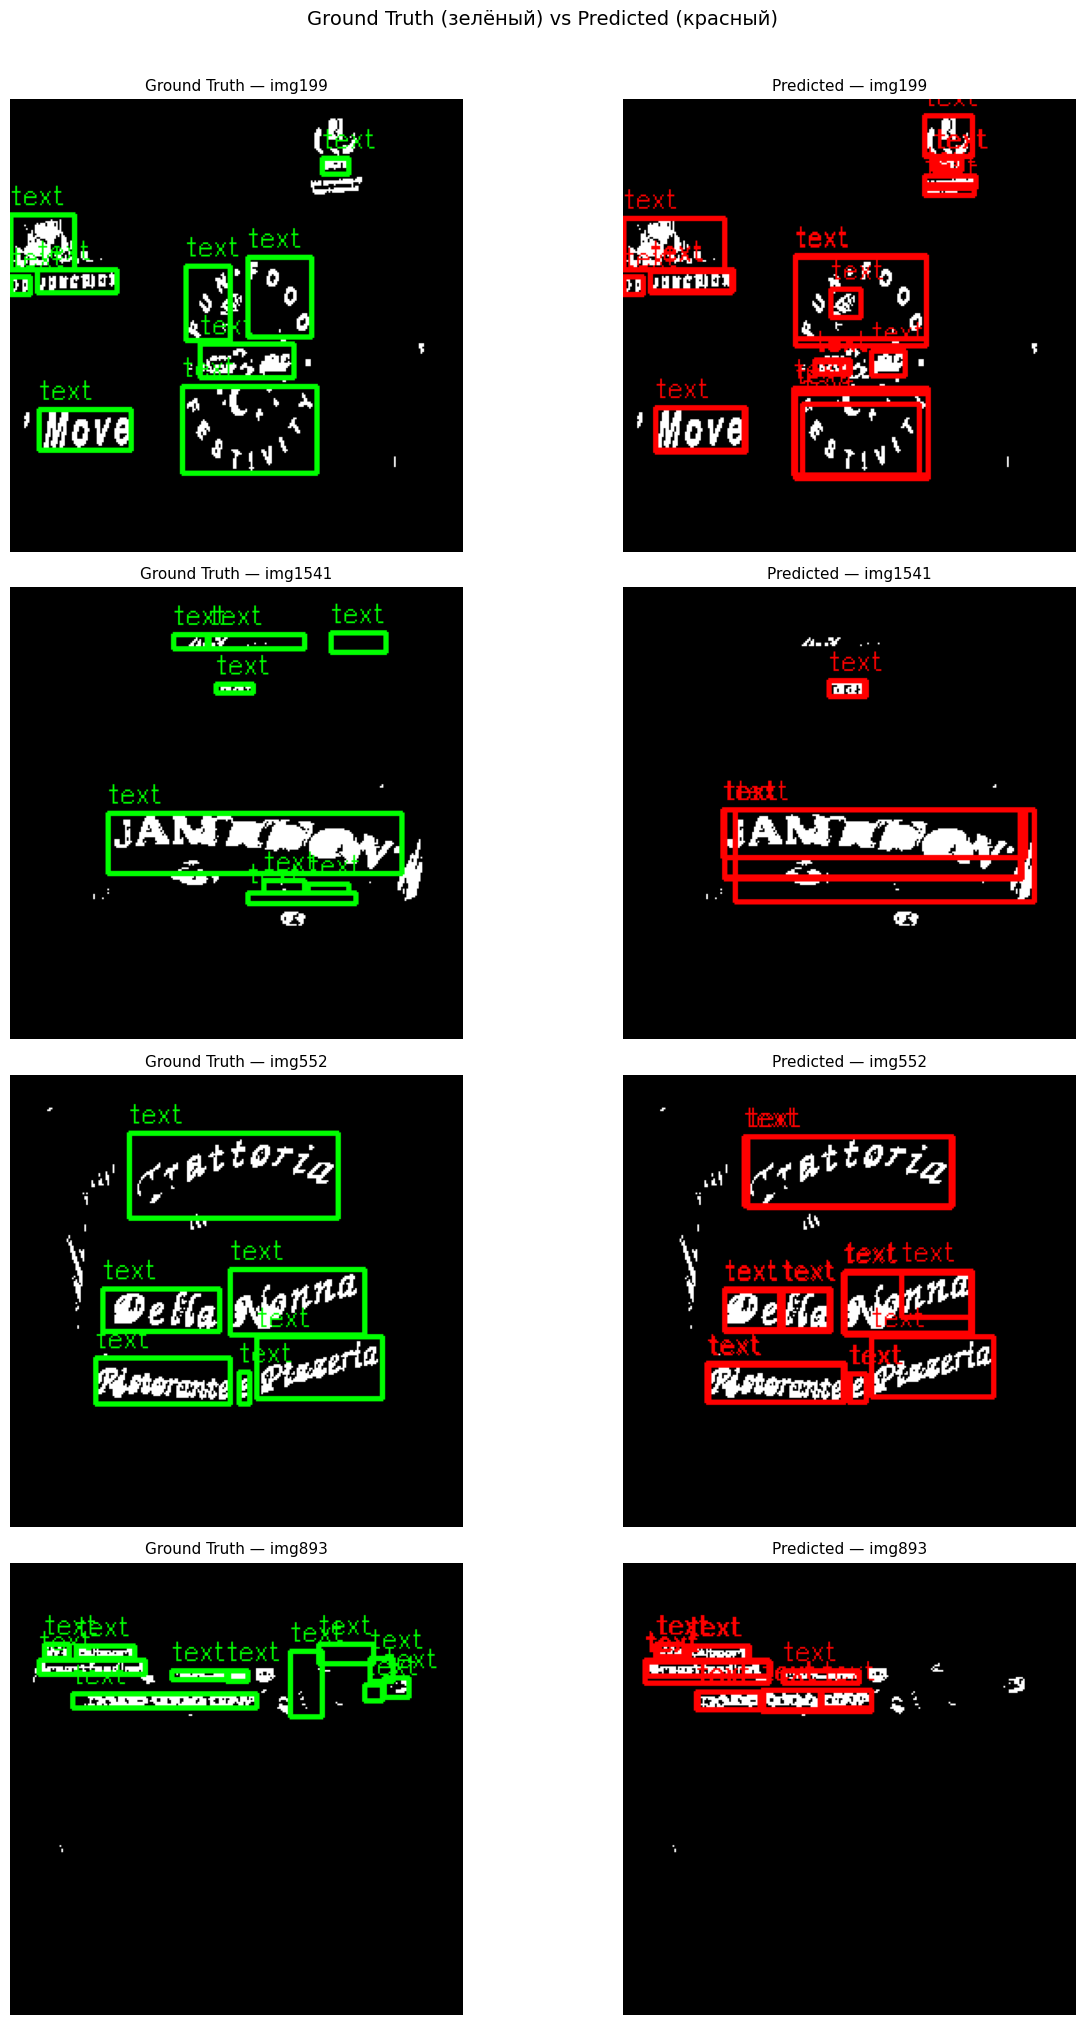

#Результаты

В результате проделанной работы, мне удалось реализовать с нуля 2 архитектуры для сегментации (не считая DeepLabV3) и 1 архитектуру для детекции (не считая детектор с Feature Pyramid Network и YOLOv8).

Лучшее качество показали - UNet + YOLOv8, mAP50 = 0.59

Считаю поставленную исследовательскую задачу выполненной.

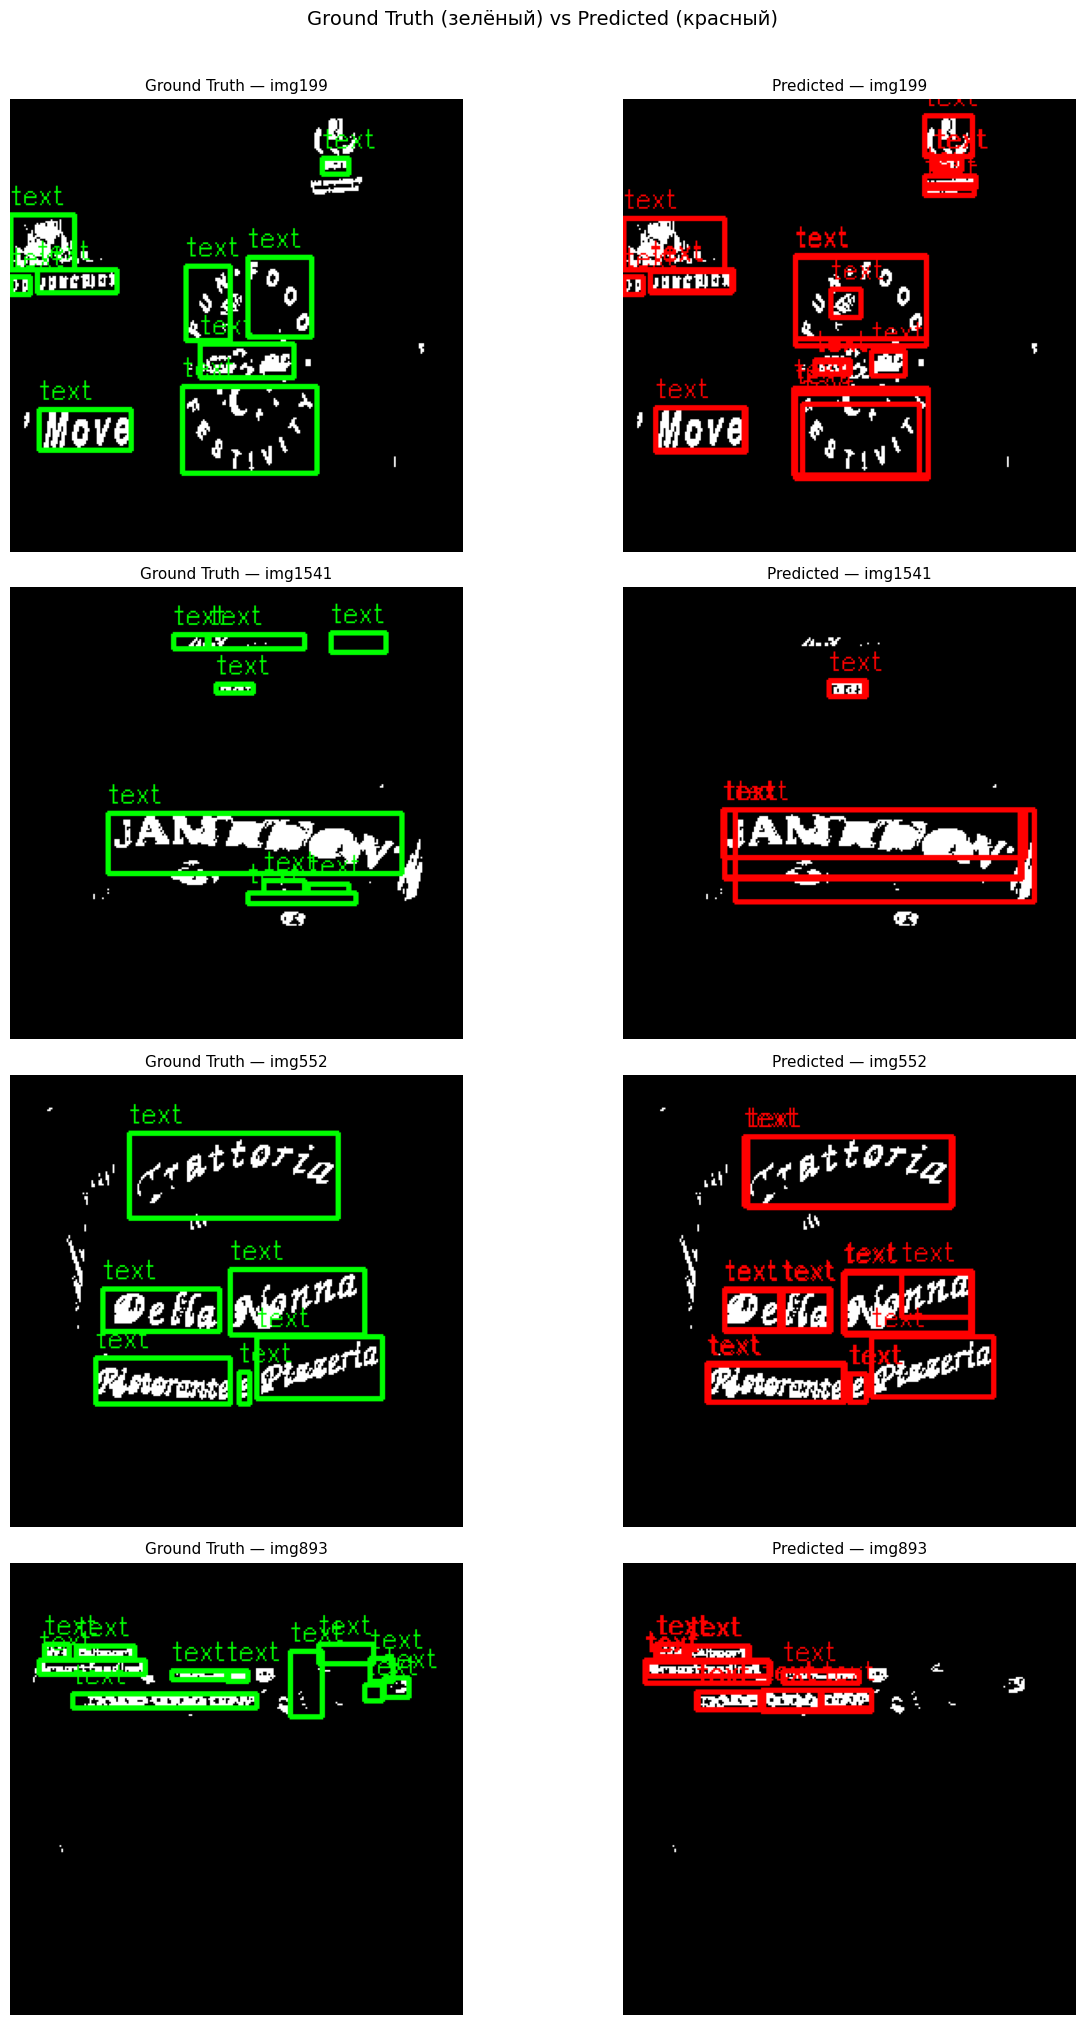